In [26]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import least_squares

# =========================================================
# FUNCIONES
# =========================================================

def delta_suave(theta, d1, d2, d3, d4):

    th = np.mod(theta, 2*np.pi)

    theta_nodes = np.array([
        0,
        np.pi/2,
        np.pi,
        3*np.pi/2,
        2*np.pi
    ])

    delta_nodes = np.array([
        d1,
        d2,
        d3,
        d4,
        d1
    ])

    return np.interp(
        th,
        theta_nodes,
        delta_nodes
    )


def model_angulo(
    theta,
    S0,
    S1,
    S2,
    S3,
    d1,
    d2,
    d3,
    d4,
    theta0,
):

    theta = theta + theta0

    delta = delta_suave(
        theta,
        d1,
        d2,
        d3,
        d4
    )

    a0 = (
        S0/2
        + S1/4*(1 + np.cos(delta))
    )

    a4c = (
        S1/4*(1 - np.cos(delta))
    )

    a4s = (
        S2/4*(1 - np.cos(delta))
    )

    a2 = (
        -S3/2*np.sin(delta)
    )

    return (
        a0
        + a2*np.sin(2*theta)
        + a4c*np.cos(4*theta)
        + a4s*np.sin(4*theta)
    )


def fit_una_vuelta_angulo(theta, I):

    # =========================================
    # ordenar
    # =========================================

    idx = np.argsort(theta)

    theta = theta[idx]
    I = I[idx]

    # =========================================
    # normalizar
    # =========================================

    I = I / np.max(I)

    S0 = np.max(I)

    # =========================================
    # errores
    # =========================================

    V_div = 0.005

    V_full_scale = 8 * V_div

    res_err = V_full_scale / 256

    I_err = np.sqrt(
        (0.03 * I)**2
        + res_err**2
    )

    # =========================================
    # residuals
    # =========================================

    def residuals(params):

        (
            S1,
            S2,
            S3,
            d1,
            d2,
            d3,
            d4,
            theta0
        ) = params

        I_model = model_angulo(
            theta,
            S0,
            S1,
            S2,
            S3,
            d1,
            d2,
            d3,
            d4,
            theta0
        )

        return (
            I_model - I
        ) / I_err

    # =========================================
    # bounds
    # =========================================

    lower_bounds = [
        -S0,
        -S0,
        -S0,
        0,
        0,
        0,
        0,
        -2*np.pi
    ]

    upper_bounds = [
        S0,
        S0,
        S0,
        2*np.pi,
        2*np.pi,
        2*np.pi,
        2*np.pi,
        2*np.pi
    ]

    # =========================================
    # multistart
    # =========================================

    best_result = None
    best_cost = np.inf

    for _ in range(20):

        guess = [

            np.random.uniform(-S0, S0),
            np.random.uniform(-S0, S0),
            np.random.uniform(-S0, S0),

            np.random.uniform(1.4, 1.9),
            np.random.uniform(1.4, 1.9),
            np.random.uniform(1.4, 1.9),
            np.random.uniform(1.4, 1.9),

            np.random.uniform(-np.pi, np.pi)
        ]

        r = least_squares(
            residuals,
            guess,
            bounds=(
                lower_bounds,
                upper_bounds
            )
        )

        if r.cost < best_cost:

            best_cost = r.cost
            best_result = r

    result = best_result


    J = result.jac

    N = len(theta)
    P = len(result.x)

    sigma2 = 2 * result.cost / (N - P)

    cov = sigma2 * np.linalg.pinv(J.T @ J)

    err = np.sqrt(np.diag(cov))

    (
        S1_fit,
        S2_fit,
        S3_fit,
        d1_fit,
        d2_fit,
        d3_fit,
        d4_fit,
        theta0_fit
    ) = result.x

    # =========================================
    # curva ajustada
    # =========================================

    theta_fit = np.linspace(
        0,
        2*np.pi,
        3000
    )

    I_fit = model_angulo(
        theta_fit,
        S0,
        S1_fit,
        S2_fit,
        S3_fit,
        d1_fit,
        d2_fit,
        d3_fit,
        d4_fit,
        theta0_fit
    )

        # =========================================
    # PLOT AJUSTE
    # =========================================

    plt.figure(figsize=(8,5))

    plt.plot(
        theta,
        I,
        "o",
        ms=4,
        label="Datos"
    )

    plt.plot(
        theta_fit,
        I_fit,
        lw=2,
        label="Ajuste"
    )

    plt.xlabel(r"$\theta$ [rad]")
    plt.ylabel("Intensidad normalizada")
    plt.grid(True)
    plt.legend()

    # =========================================
    # ESFERA DE POINCARE
    # =========================================

    from mpl_toolkits.mplot3d import Axes3D

    fig = plt.figure(figsize=(6,6))
    ax = fig.add_subplot(111, projection="3d")

    # esfera
    u = np.linspace(0,2*np.pi,60)
    v = np.linspace(0,np.pi,30)

    x = np.outer(np.cos(u),np.sin(v))
    y = np.outer(np.sin(u),np.sin(v))
    z = np.outer(np.ones_like(u),np.cos(v))

    ax.plot_wireframe(
        x,
        y,
        z,
        color="lightgray",
        linewidth=0.5
    )

    # ejes
    ax.plot([-1,1],[0,0],[0,0],'k')
    ax.plot([0,0],[-1,1],[0,0],'k')
    ax.plot([0,0],[0,0],[-1,1],'k')

    # punto medido
    s1 = S1_fit / S0
    s2 = S2_fit / S0
    s3 = S3_fit / S0

    DOP = np.sqrt(
    s1**2 +
    s2**2 +
    s3**2)

    err_s1 = err[0] / S0
    err_s2 = err[1] / S0
    err_s3 = err[2] / S0

    err_DOP = np.sqrt((s1/DOP * err_s1)**2 +(s2/DOP * err_s2)**2 +(s3/DOP * err_s3)**2)

    ax.scatter(
        s1,
        s2,
        s3,
        color="red",
        s=80
    )

    ax.plot(
        [0,s1],
        [0,s2],
        [0,s3],
        color="red"
    )

    ax.set_xlabel(r"$S_1/S_0$")
    ax.set_ylabel(r"$S_2/S_0$")
    ax.set_zlabel(r"$S_3/S_0$")

    ax.set_xlim([-1,1])
    ax.set_ylim([-1,1])
    ax.set_zlim([-1,1])

    ax.set_box_aspect((1,1,1))


    resultados = {

        "s1": s1,
        "s2": s2,
        "s3": s3,

        "err_s1": err_s1,
        "err_s2": err_s2,
        "err_s3": err_s3,

        "DOP": DOP,
        "err_DOP": err_DOP,
        "d1": d1_fit,
        "d2": d2_fit,
        "d3": d3_fit,
        "d4": d4_fit,

        "err_d1": err[3],
        "err_d2": err[4],
        "err_d3": err[5],
        "err_d4": err[6],

        "theta0": theta0_fit,
        "err_theta0": err[7],

        "theta_fit": theta_fit,
        "I_fit": I_fit
    }

    print("\n========== VECTOR DE POINCARÉ ==========")
    print(f"S1/S0 = {s1:.5f} ± {err_s1:.5f}")
    print(f"S2/S0 = {s2:.5f} ± {err_s2:.5f}")
    print(f"S3/S0 = {s3:.5f} ± {err_s3:.5f}")
    print(f"\nDOP = {DOP:.5f} ± {err_DOP:.5f}")

    print("\n========== DELTAS ==========")
    print(f"δ1 = {d1_fit:.5f} ± {err[3]:.5f} rad")
    print(f"δ2 = {d2_fit:.5f} ± {err[4]:.5f} rad")
    print(f"δ3 = {d3_fit:.5f} ± {err[5]:.5f} rad")
    print(f"δ4 = {d4_fit:.5f} ± {err[6]:.5f} rad")

    print(f"\nθ0 = {theta0_fit:.5f} ± {err[7]:.5f} rad")

    return resultados


In [ ]:
# import pandas as pd

# df = pd.read_csv(r"C:\Users\barcr\OneDrive\Documents\Polarimetro\mediciones_continuo\bloque_0000_0001.csv")

# time=df["tiempo_us"].to_numpy()
# voltaje = df["voltaje_V"].to_numpy()
# vueltas=df["vuelta"].to_numpy()


# time = time[:-1]
# voltaje = voltaje[:-1]
# vueltas = vueltas[:-1]


# #resultado = fit_una_vuelta_angulo(theta, I)

# theta_common = np.linspace(
#     0,
#     2*np.pi,
#     500
# )

# lista = list(range(1, 18))

# I_all = []

# for n in lista:

#     t = time[vueltas == n]
#     I = voltaje[vueltas == n]

#     idx = np.argsort(t)

#     t = t[idx]
#     I = I[idx]

#     # ángulo de la vuelta
#     theta= (
#         2*np.pi
#         * (t - t.min())
#         / (t.max() - t.min())
#     )

#     I_interp = np.interp(
#         theta_common,
#         theta,
#         I
#     )

#     I_all.append(I_interp)

# I_all = np.array(I_all)

# # promedio

# I_mean = np.mean(
#     I_all,
#     axis=0
# )

# I_std = np.std(
#     I_all,
#     axis=0
# )


# resultado = fit_una_vuelta_angulo(theta, I)

ValueError: zero-size array to reduction operation minimum which has no identity

In [34]:
df_1 = pd.read_csv(r"C:\Users\barcr\OneDrive\Documents\Polarimetro\mediciones_continuo\bloque_0000_0001.csv")
df_2 = pd.read_csv(r"C:\Users\barcr\OneDrive\Documents\Polarimetro\mediciones_continuo\bloque_0002_0003.csv")
df_3 = pd.read_csv(r"C:\Users\barcr\OneDrive\Documents\Polarimetro\mediciones_continuo\bloque_0004_0005.csv")
df_4 = pd.read_csv(r"C:\Users\barcr\OneDrive\Documents\Polarimetro\mediciones_continuo\bloque_0006_0007.csv")
df_5 = pd.read_csv(r"C:\Users\barcr\OneDrive\Documents\Polarimetro\mediciones_continuo\bloque_0008_0009.csv")
df_6 = pd.read_csv(r"C:\Users\barcr\OneDrive\Documents\Polarimetro\mediciones_continuo\bloque_0010_0011.csv")
df_7 = pd.read_csv(r"C:\Users\barcr\OneDrive\Documents\Polarimetro\mediciones_continuo\bloque_0012_0013.csv")
df_8 = pd.read_csv(r"C:\Users\barcr\OneDrive\Documents\Polarimetro\mediciones_continuo\bloque_0014_0015.csv")
df_9 = pd.read_csv(r"C:\Users\barcr\OneDrive\Documents\Polarimetro\mediciones_continuo\bloque_0016_0017.csv")
df_10 = pd.read_csv(r"C:\Users\barcr\OneDrive\Documents\Polarimetro\mediciones_continuo\bloque_0018_0019.csv")
df_11 = pd.read_csv(r"C:\Users\barcr\OneDrive\Documents\Polarimetro\mediciones_continuo\bloque_0020_0021.csv")
df_12 = pd.read_csv(r"C:\Users\barcr\OneDrive\Documents\Polarimetro\mediciones_continuo\bloque_0022_0023.csv")

In [37]:
dfs=[df_1,df_2,df_3,df_4,df_5,df_6,df_7,df_8,df_9,df_10,df_11,df_12]


========== VECTOR DE POINCARÉ ==========
S1/S0 = 0.52174 ± 0.03616
S2/S0 = -0.00665 ± 0.10592
S3/S0 = -1.00000 ± 0.04971

DOP = 1.12794 ± 0.04714

========== DELTAS ==========
δ1 = 4.09149 ± 0.21010 rad
δ2 = 0.59051 ± 0.12834 rad
δ3 = 0.56034 ± 0.12903 rad
δ4 = 4.07516 ± 0.21045 rad

θ0 = -1.01950 ± 0.02685 rad

========== VECTOR DE POINCARÉ ==========
S1/S0 = 0.92276 ± 0.01654
S2/S0 = 0.26105 ± 0.11079
S3/S0 = -0.16576 ± 0.00440

DOP = 0.97320 ± 0.03361

========== DELTAS ==========
δ1 = 1.52138 ± 0.02488 rad
δ2 = 1.62457 ± 0.04766 rad
δ3 = 1.53956 ± 0.02427 rad
δ4 = 1.66746 ± 0.04662 rad

θ0 = -1.45124 ± 0.02871 rad

========== VECTOR DE POINCARÉ ==========
S1/S0 = 0.90992 ± 0.01877
S2/S0 = 0.29769 ± 0.11207
S3/S0 = -0.16269 ± 0.00449

DOP = 0.97110 ± 0.03860

========== DELTAS ==========
δ1 = 1.56338 ± 0.02421 rad
δ2 = 1.62650 ± 0.04964 rad
δ3 = 1.55747 ± 0.02448 rad
δ4 = 1.59835 ± 0.05024 rad

θ0 = -4.56528 ± 0.02910 rad

========== VECTOR DE POINCARÉ ==========
S1/S0 = 0.91959 ± 

C:\Users\barcr\AppData\Local\Temp\ipykernel_13400\989778570.py:268: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(8,5))



========== VECTOR DE POINCARÉ ==========
S1/S0 = 0.91949 ± 0.01624
S2/S0 = 0.27268 ± 0.10446
S3/S0 = -0.16345 ± 0.00408

DOP = 0.97290 ± 0.03306

========== DELTAS ==========
δ1 = 1.54549 ± 0.02299 rad
δ2 = 1.61362 ± 0.04513 rad
δ3 = 1.55275 ± 0.02251 rad
δ4 = 1.65820 ± 0.04447 rad

θ0 = -1.47764 ± 0.02709 rad

========== VECTOR DE POINCARÉ ==========
S1/S0 = 0.91718 ± 0.01816
S2/S0 = 0.28957 ± 0.11222
S3/S0 = -0.16331 ± 0.00439

DOP = 0.97557 ± 0.03744

========== DELTAS ==========
δ1 = 1.53994 ± 0.02366 rad
δ2 = 1.64974 ± 0.04851 rad
δ3 = 1.53462 ± 0.02401 rad
δ4 = 1.61685 ± 0.04909 rad

θ0 = 1.70378 ± 0.02899 rad


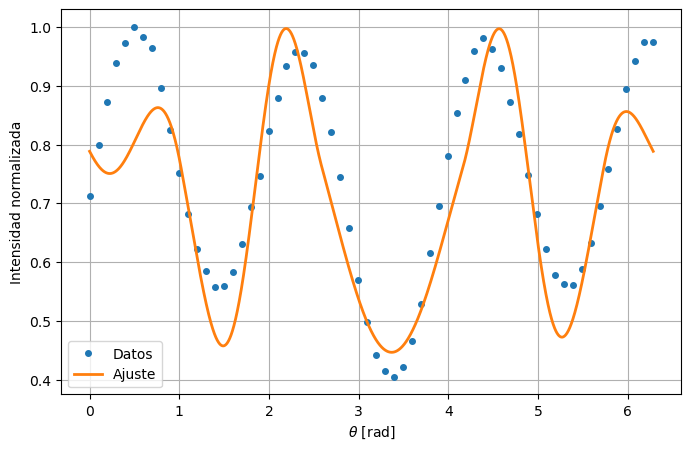

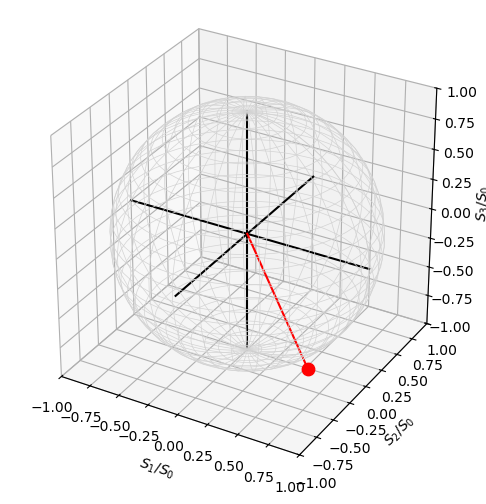

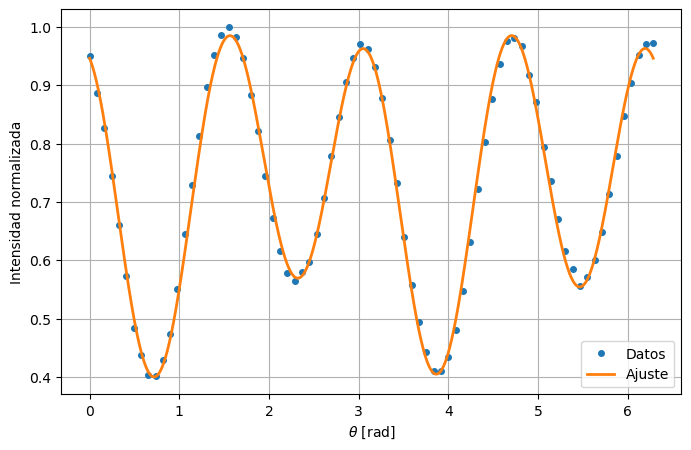

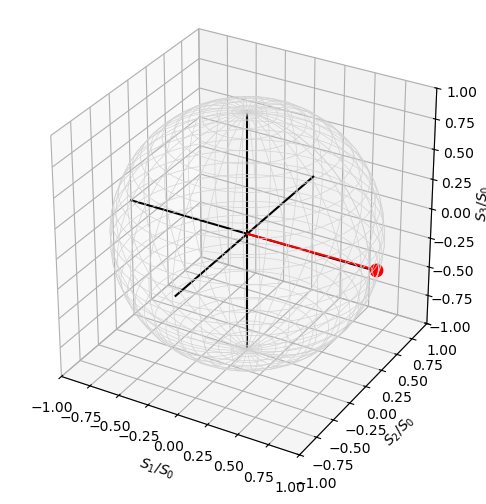

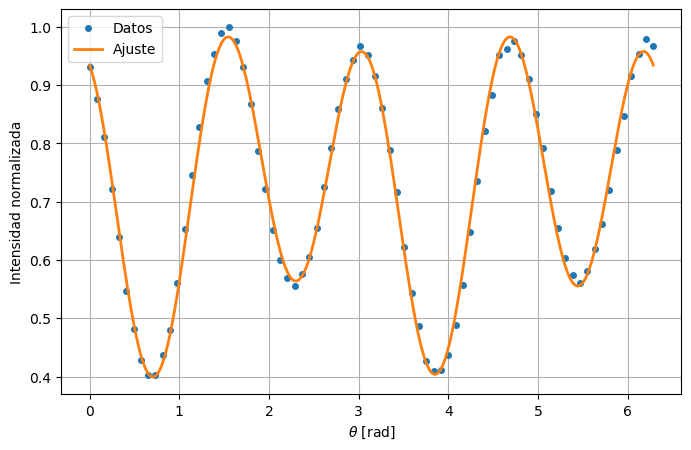

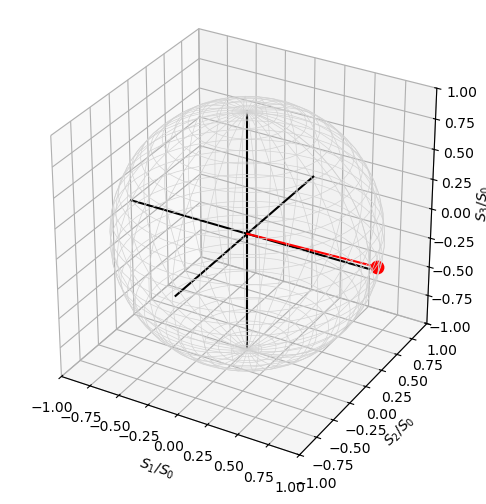

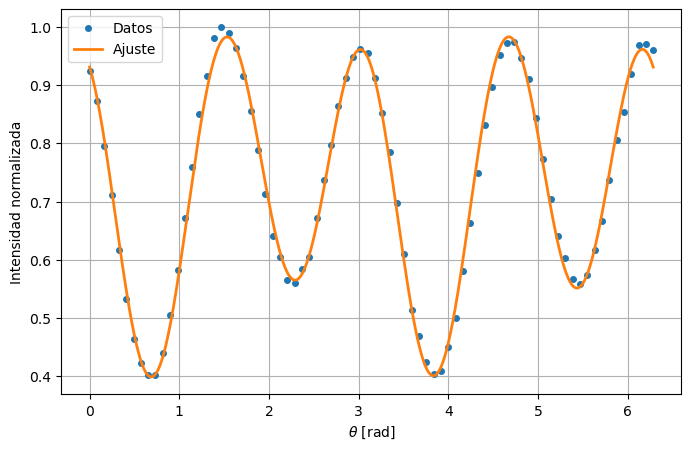

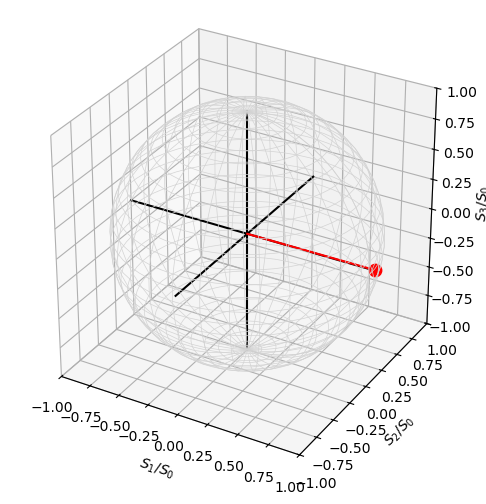

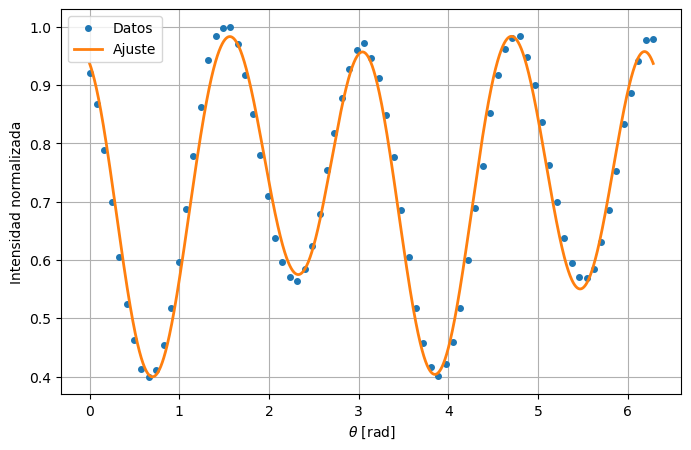

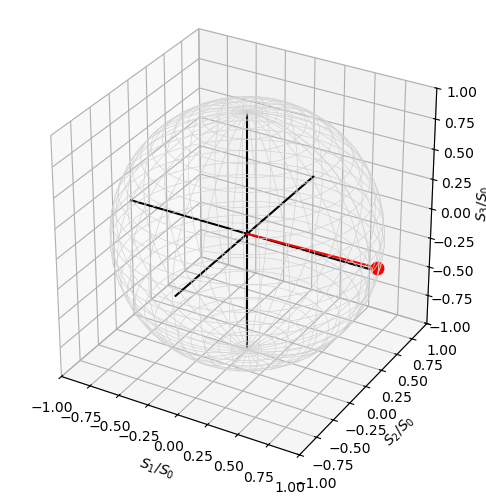

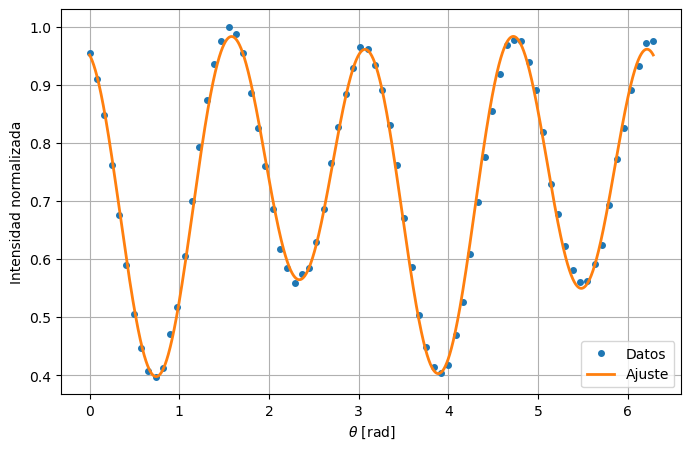

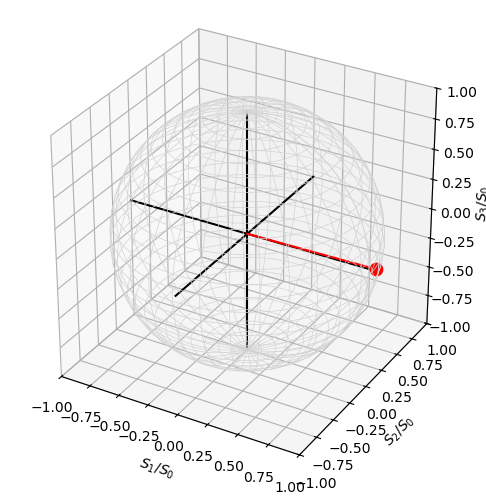

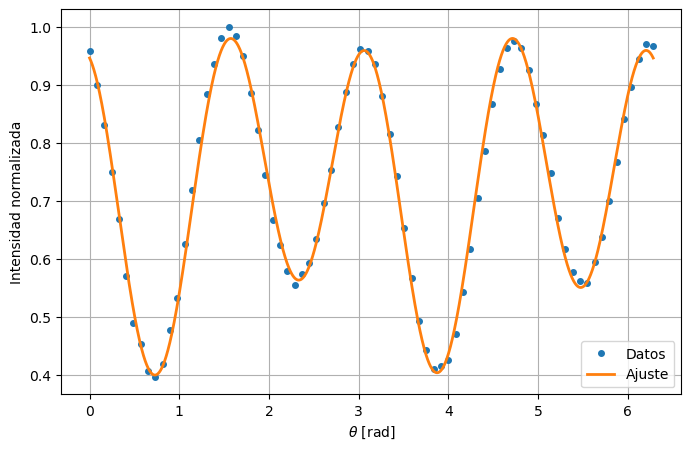

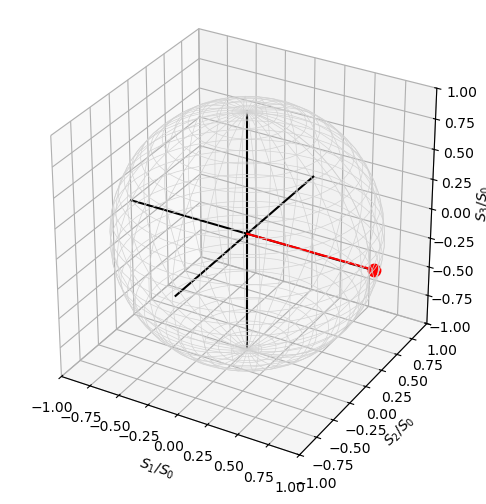

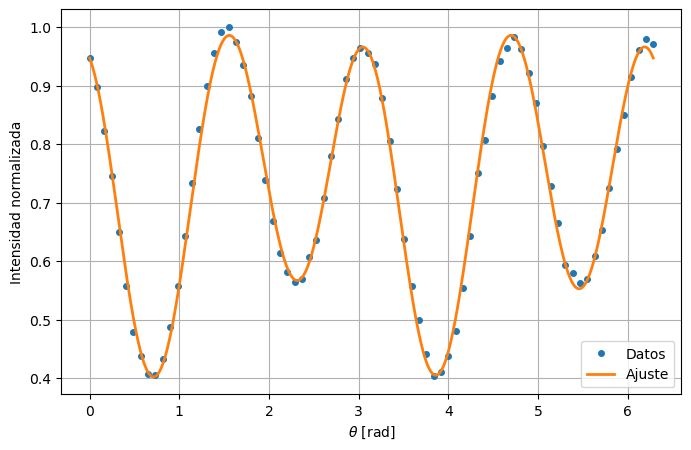

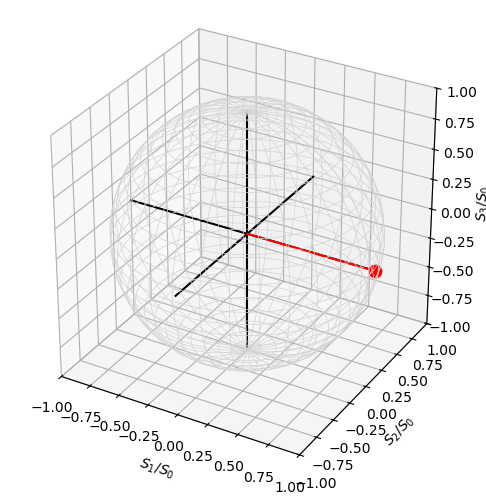

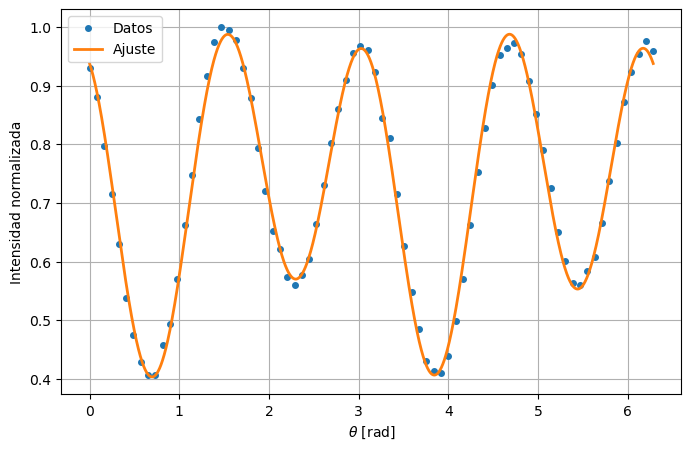

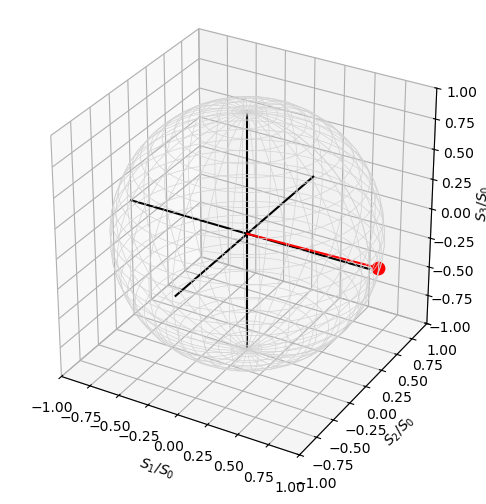

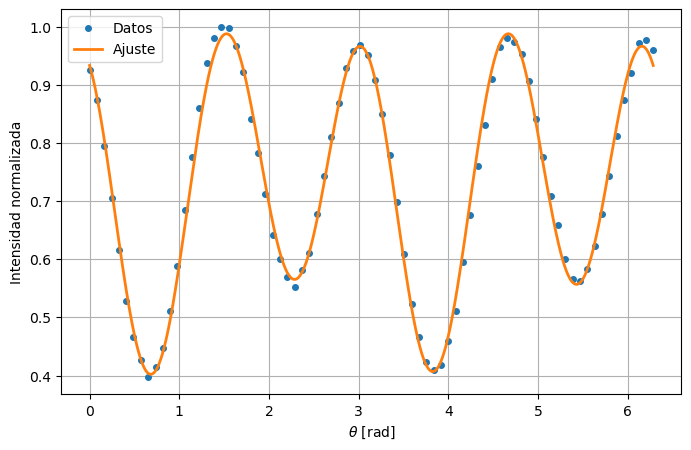

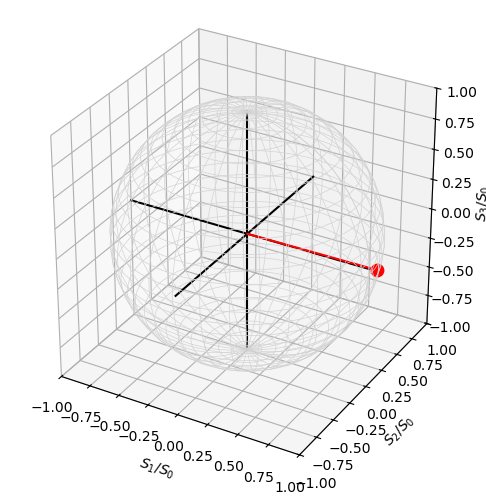

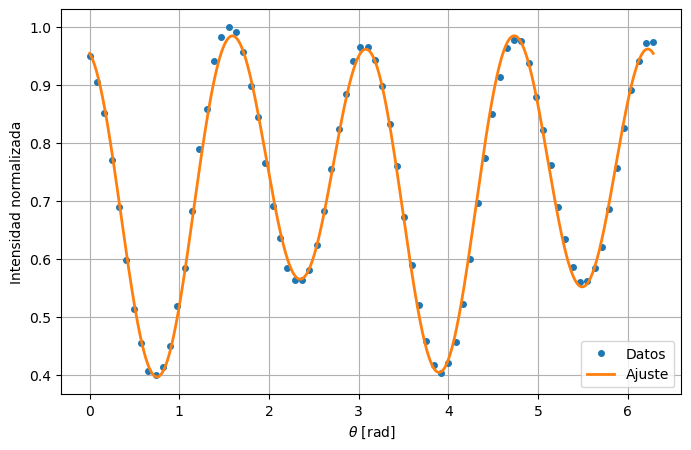

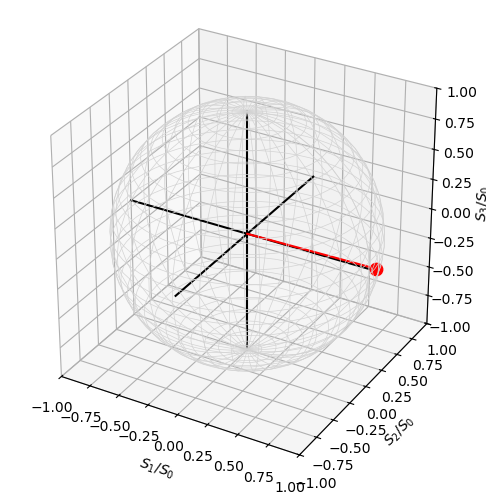

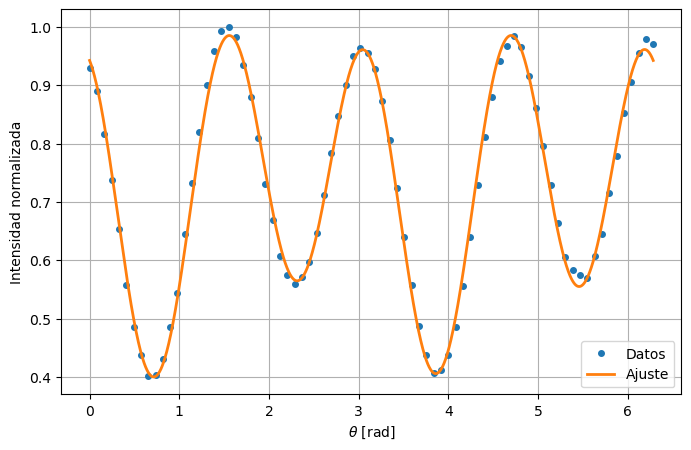

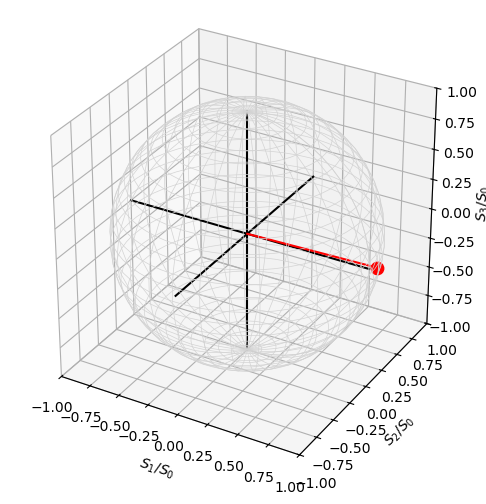

In [39]:
S1s = []
S2s = []
S3s = []

for df in dfs:

    time = df["tiempo_us"].to_numpy()[:-1]
    voltaje = df["voltaje_V"].to_numpy()[:-1]
    vueltas = df["vuelta"].to_numpy()[:-1]

    theta = 2*np.pi*(time-time.min())/(time.max()-time.min())

    I = voltaje

    resultado = fit_una_vuelta_angulo(theta, I)
    S1s.append(resultado["s1"])
    S2s.append(resultado["s2"])
    S3s.append(resultado["s3"])


========== VECTOR DE POINCARÉ ==========
S1/S0 = 0.92276 ± 0.01654
S2/S0 = 0.26105 ± 0.11079
S3/S0 = -0.16576 ± 0.00440

DOP = 0.97320 ± 0.03361

========== DELTAS ==========
δ1 = 1.52138 ± 0.02488 rad
δ2 = 1.62457 ± 0.04766 rad
δ3 = 1.53956 ± 0.02427 rad
δ4 = 1.66746 ± 0.04662 rad

θ0 = -1.45124 ± 0.02871 rad


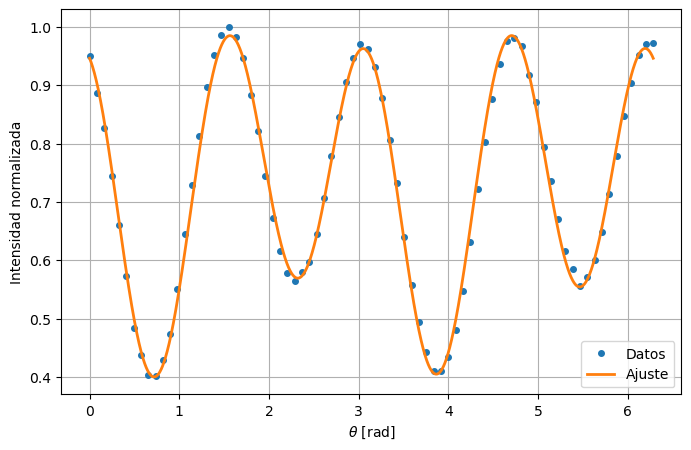

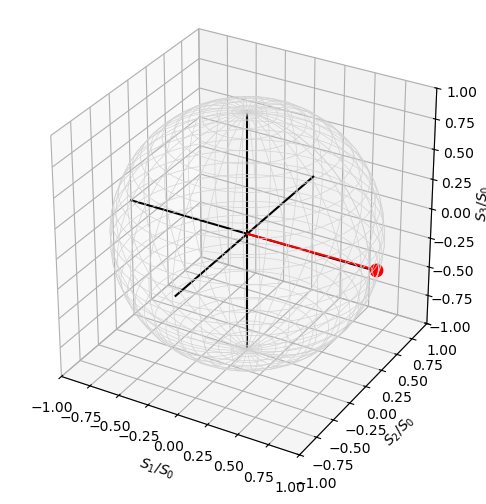

In [29]:
I=voltaje
resultado = fit_una_vuelta_angulo(theta, I)

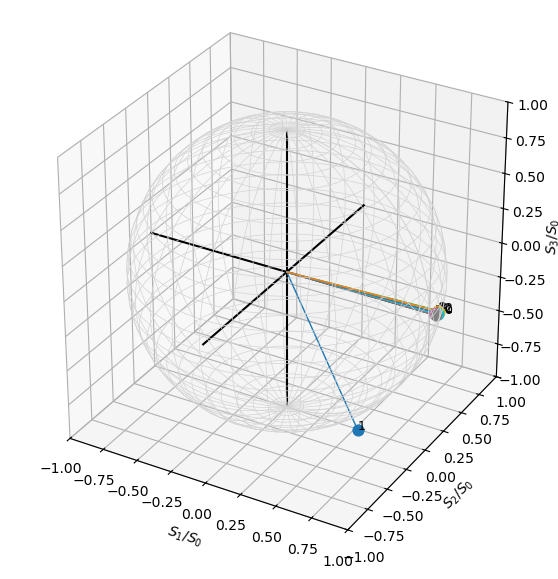

In [40]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection="3d")

# Esfera
u = np.linspace(0, 2*np.pi, 60)
v = np.linspace(0, np.pi, 30)

x = np.outer(np.cos(u), np.sin(v))
y = np.outer(np.sin(u), np.sin(v))
z = np.outer(np.ones_like(u), np.cos(v))

ax.plot_wireframe(x, y, z, color="lightgray", linewidth=0.5)

# Ejes
ax.plot([-1,1],[0,0],[0,0],'k')
ax.plot([0,0],[-1,1],[0,0],'k')
ax.plot([0,0],[0,0],[-1,1],'k')

# Todos los vectores
for i in range(len(S1s)):

    ax.scatter(S1s[i], S2s[i], S3s[i], s=60)

    ax.plot(
        [0, S1s[i]],
        [0, S2s[i]],
        [0, S3s[i]],
        lw=1
    )

    # opcional: numerar cada medición
    ax.text(
        S1s[i],
        S2s[i],
        S3s[i],
        str(i+1),
        fontsize=9
    )

ax.set_xlabel(r"$S_1/S_0$")
ax.set_ylabel(r"$S_2/S_0$")
ax.set_zlabel(r"$S_3/S_0$")

ax.set_xlim([-1,1])
ax.set_ylim([-1,1])
ax.set_zlim([-1,1])

ax.set_box_aspect((1,1,1))

plt.show()

In [ ]:
df_1 = pd.read_csv(r"C:\Users\barcr\OneDrive\Documents\Polarimetro\mediciones_continuo\bloque_0000_0001.csv")
df_2 = pd.read_csv(r"C:\Users\barcr\OneDrive\Documents\Polarimetro\mediciones_continuo\bloque_0002_0003.csv")
df_3 = pd.read_csv(r"C:\Users\barcr\OneDrive\Documents\Polarimetro\mediciones_continuo\bloque_0004_0005.csv")
df_4 = pd.read_csv(r"C:\Users\barcr\OneDrive\Documents\Polarimetro\mediciones_continuo\bloque_0006_0007.csv")
df_5 = pd.read_csv(r"C:\Users\barcr\OneDrive\Documents\Polarimetro\mediciones_continuo\bloque_0008_0009.csv")
df_6 = pd.read_csv(r"C:\Users\barcr\OneDrive\Documents\Polarimetro\mediciones_continuo\bloque_0010_0011.csv")
df_7 = pd.read_csv(r"C:\Users\barcr\OneDrive\Documents\Polarimetro\mediciones_continuo\bloque_0012_0013.csv")
df_8 = pd.read_csv(r"C:\Users\barcr\OneDrive\Documents\Polarimetro\mediciones_continuo\bloque_0014_0015.csv")
df_9 = pd.read_csv(r"C:\Users\barcr\OneDrive\Documents\Polarimetro\mediciones_continuo\bloque_0016_0017.csv")
df_10 = pd.read_csv(r"C:\Users\barcr\OneDrive\Documents\Polarimetro\mediciones_continuo\bloque_0018_0019.csv")
df_11 = pd.read_csv(r"C:\Users\barcr\OneDrive\Documents\Polarimetro\mediciones_continuo\bloque_0020_0021.csv")
df_12 = pd.read_csv(r"C:\Users\barcr\OneDrive\Documents\Polarimetro\mediciones_continuo\bloque_0022_0023.csv")

In [ ]:
S1s = []
S2s = []
S3s = []

for df in dfs:

    time = df["tiempo_us"].to_numpy()[:-1]
    voltaje = df["voltaje_V"].to_numpy()[:-1]
    vueltas = df["vuelta"].to_numpy()[:-1]

    theta = 2*np.pi*(time-time.min())/(time.max()-time.min())

    I = voltaje

    resultado = fit_una_vuelta_angulo(theta, I)
    S1s.append(resultado["s1"])
    S2s.append(resultado["s2"])
    S3s.append(resultado["s3"])